# Davies-Bouldin index

scikit-learn and back-of-envelop calculations

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import metrics, datasets, cluster

In [2]:
def calcdb(X, y):
    n_clusters = len(np.unique(y))
    xx, yy = [], []
    for u in np.unique(y):
        xx.append(X[np.where(y==u)[0], 0])
        yy.append(X[np.where(y==u)[0], 1])
    centroid = np.zeros((len(np.unique(y)), 2))
    for n_cluster, (xxx, yyy) in enumerate(zip(xx, yy)):
        centroid[n_cluster, :] = [np.mean(xxx), np.mean(yyy)]

    s = np.zeros(n_clusters)
    ns = np.zeros(n_clusters)
    for xxx, yyy in zip(X, y):
        s[yyy] += np.linalg.norm(xxx - centroid[yyy])
        ns[yyy] += 1
    s /= ns

    R = []
    for ki in range(n_clusters):
        RR = []
        for kj in range(n_clusters):
            if ki != kj:
                d = np.linalg.norm(centroid[ki, :]-centroid[kj, :])
                RR.append( (s[ki]+s[kj]) / d )
                d = np.linalg.norm(centroid[kj, :]-centroid[ki, :])
                RR.append( (s[ki]+s[kj]) / d )
        R.append(max(RR))
    DB = np.sum(R)/n_clusters
    return DB

## Example #1

In [3]:
X = [[-1, -1],
     [-1,  1],
     [ 1, -1],
     [ 1,  1]]
y = [0, 1, 0, 1]
X = np.array(X); y = np.array(y)

print('DB score calculated using scikit-learn:', metrics.davies_bouldin_score(X, y))
print('DB score calculated semi-automatically:', calcdb(X, y))

DB score calculated using scikit-learn: 1.0
DB score calculated semi-automatically: 1.0


Manual back-of-envelop calculation

si = average distance between each point of cluster i and cluster centroid

dij = distance between cluster centroids i and j

Rij = (si + sj) / dij

s0, s1 = 1, 1

dij = 2

Rij = 1

DB = (1 + 1)/2 = 1

## Example #2

In [4]:
X = [[-1, -2],
     [-3,  4],
     [ 5, -6],
     [ 7,  8]]
y = [0, 1, 1, 1]
X = np.array(X); y = np.array(y)

print('DB score calculated using scikit-learn:', metrics.davies_bouldin_score(X, y))
print('DB score calculated semi-automatically:', calcdb(X, y))

DB score calculated using scikit-learn: 1.2835089469531387
DB score calculated semi-automatically: 1.2835089469531387


## Two concentric circles

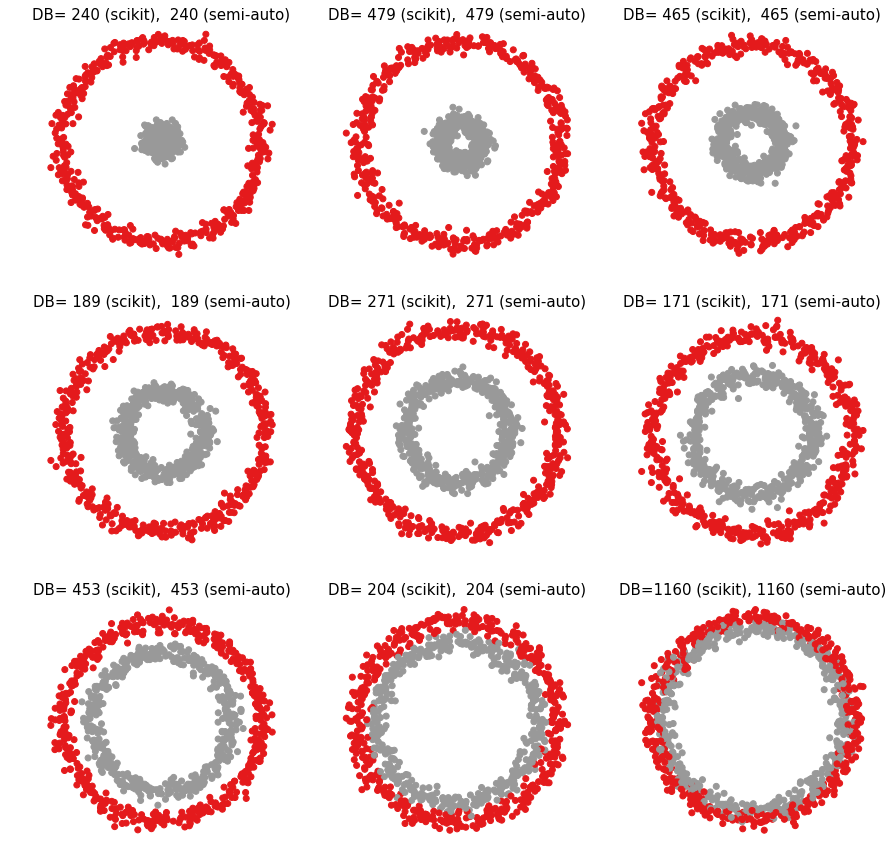

In [5]:
np.random.seed(77)
n_samples = 1000
plt.figure(figsize=(15, 15)); plt.set_cmap('Set1')
for n, factor in enumerate(np.arange(.1, 1, .1)):
    X, y = datasets.make_circles(n_samples=n_samples, factor=factor, noise=.05)
    plt.subplot(3, 3, n+1)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.axis('equal'); plt.axis('off')
    plt.title('DB={:4.0f} (scikit), {:4.0f} (semi-auto)'.format(
        metrics.davies_bouldin_score(X, y), calcdb(X, y)), size=15)

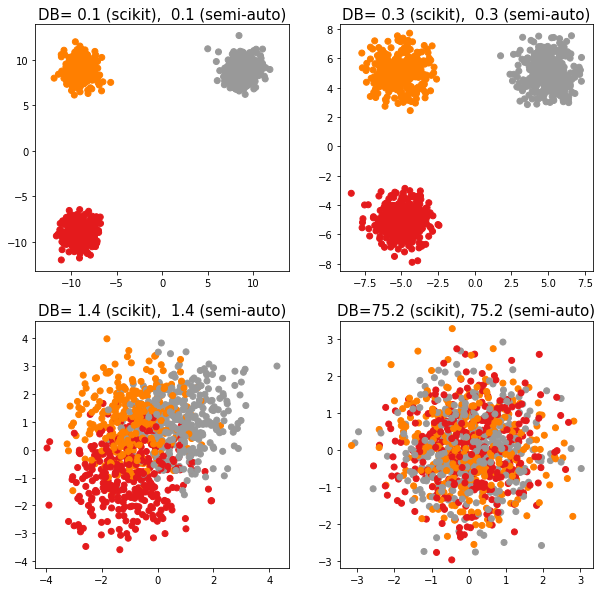

In [6]:
centerss = [[[-9, -9], [-9, 9], [9, 9]],
            [[-5, -5], [-5, 5], [5, 5]],
            [[-1, -1], [-1, 1], [1, 1]],
            [[ 0,  0], [ 0, 0], [0, 0]]]
plt.figure(figsize=(10, 10)); plt.set_cmap('Set1')
for n, centers in enumerate(centerss):         
    plt.subplot(2, 2, n+1)
    X, y = datasets.make_blobs(n_samples=n_samples, centers=centers)
    plt.scatter(X[:, 0], X[:, 1], c=y)
    plt.axis('equal')
    plt.title('DB={:4.1f} (scikit), {:4.1f} (semi-auto)'.format(
        metrics.davies_bouldin_score(X, y), calcdb(X, y)), size=15)